In [1]:
import csv
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, mean_absolute_error
import myRegression

In [2]:

def loadData(fileName, inputVars, outputVar):
    if isinstance(inputVars, str):
        inputVars = [inputVars]
    data, dataNames = [], []
    with open(fileName) as f:
        reader = csv.reader(f, delimiter=',')
        for i, row in enumerate(reader):
            if i == 0:
                dataNames = row
            else:
                data.append(row)
    idx_in  = [dataNames.index(v) for v in inputVars]
    idx_out = dataNames.index(outputVar)
    inputs, outputs = [], []
    skipped = 0
    for row in data:
        try:
            ins = [float(row[j]) for j in idx_in]
            out = float(row[idx_out])
            inputs.append(ins[0] if len(ins)==1 else ins)
            outputs.append(out)
        except (ValueError, IndexError):
            skipped += 1
    print(f"  Loaded {len(outputs)} rows, skipped {skipped} rows cu date invalide")
    return inputs, outputs


def splitTrainTest(inputs, outputs):
    np.random.seed(5)
    indexes = list(range(len(outputs)))
    trainIndexes = list(np.random.choice(indexes, int(0.8 * len(outputs)), replace=False))
    testIndexes = [i for i in indexes if i not in trainIndexes]
    
    trainIn  = [inputs[i]  for i in trainIndexes]
    trainOut = [outputs[i] for i in trainIndexes]
    testIn   = [inputs[i]  for i in testIndexes]
    testOut  = [outputs[i] for i in testIndexes]
    return trainIn, trainOut, testIn, testOut


def evalMetrics(realOut, predOut, label=""):
    mse = mean_squared_error(realOut, predOut)
    mae = mean_absolute_error(realOut, predOut)
    print(f"{label}  MSE = {mse:.4f}  |  MAE = {mae:.4f}")
    return mse, mae

def evalMetricsManual(realOut, predOut, label=""):
    mse = myRegression.myMSE(realOut, predOut)
    mae = myRegression.myMAE(realOut, predOut)
    print(f"{label}  MSE manual = {mse:.4f}  |  MAE manual = {mae:.4f}")
    return mse, mae


def plotScatter(trainIn, trainOut, testIn, testOut, xref=None, yref=None, xlabel="x", title=""):
    plt.figure(figsize=(7, 4))
    plt.plot(trainIn, trainOut, 'ro', alpha=0.6, label='train')
    plt.plot(testIn,  testOut,  'g^', alpha=0.6, label='test')
    if xref is not None:
        plt.plot(xref, yref, 'b-', linewidth=2, label='model')
    plt.xlabel(xlabel); plt.ylabel('Happiness Score')
    plt.title(title); plt.legend(); plt.tight_layout(); plt.show()

  Loaded 155 rows, skipped 0 rows cu date invalide
Model GDP (sklearn):  f(x) = 3.2008 + 2.1503 * x
[sklearn GDP]  MSE = 0.4142  |  MAE = 0.5588


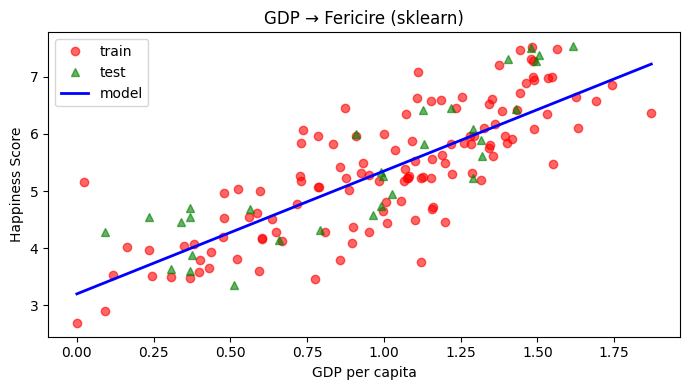

In [3]:
filePath1 = 'data/v1_world-happiness-report-2017.csv'

inputs, outputs = loadData(filePath1, 'Economy..GDP.per.Capita.', 'Happiness.Score')
trainIn, trainOut, testIn, testOut = splitTrainTest(inputs, outputs)

reg_gdp = linear_model.LinearRegression()
reg_gdp.fit([[x] for x in trainIn], trainOut)
w0, w1 = reg_gdp.intercept_, reg_gdp.coef_[0]
print(f"Model GDP (sklearn):  f(x) = {w0:.4f} + {w1:.4f} * x")

predTest = reg_gdp.predict([[x] for x in testIn])
evalMetrics(testOut, predTest, "[sklearn GDP]")

xref = np.linspace(min(trainIn), max(trainIn), 200)
yref = w0 + w1 * xref
plotScatter(trainIn, trainOut, testIn, testOut, xref, yref, 'GDP per capita', 'GDP → Fericire (sklearn)')

Model GDP (cod propriu):  f(x) = 3.2008 + 2.1503 * x
[cod propriu GDP]  MSE manual = 0.4142  |  MAE manual = 0.5588


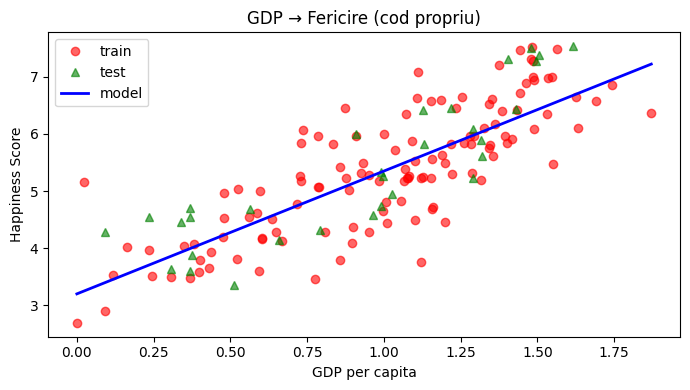

In [4]:

reg_own = myRegression.MyLinearUnivariateRegression()
reg_own.fit(trainIn, trainOut)
w0o, w1o = reg_own.intercept_, reg_own.coef_
print(f"Model GDP (cod propriu):  f(x) = {w0o:.4f} + {w1o:.4f} * x")

predOwn = reg_own.predict(testIn)
evalMetricsManual(testOut, predOwn, "[cod propriu GDP]")

xref = np.linspace(min(trainIn), max(trainIn), 200)
yref = w0o + w1o * xref
plotScatter(trainIn, trainOut, testIn, testOut, xref, yref, 'GDP per capita', 'GDP → Fericire (cod propriu)')

  Loaded 155 rows, skipped 0 rows cu date invalide
Model Family (sklearn):  f(x) = 0.4719 + 3.2329 * x
[sklearn Family]  MSE = 1.4890  |  MAE = 1.0411


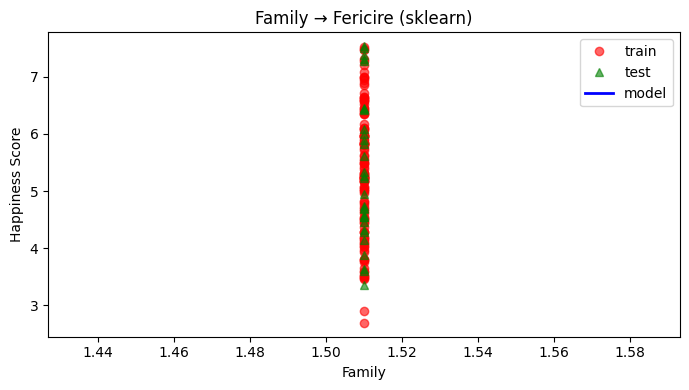

In [5]:
inputs_fam, outputs_fam = loadData(filePath1, 'Family', 'Happiness.Score')
trFamIn, trFamOut, teFamIn, teFamOut = splitTrainTest(inputs_fam, outputs_fam)

reg_fam = linear_model.LinearRegression()
reg_fam.fit([[x] for x in trFamIn], trFamOut)
w0f, w1f = reg_fam.intercept_, reg_fam.coef_[0]
print(f"Model Family (sklearn):  f(x) = {w0f:.4f} + {w1f:.4f} * x")

predFam = reg_fam.predict([[x] for x in teFamIn])
evalMetrics(teFamOut, predFam, "[sklearn Family]")

xref = np.linspace(min(trFamIn), max(trFamIn), 200)
yref = w0f + w1f * xref
plotScatter(trFamIn, trFamOut, teFamIn, teFamOut, xref, yref, 'Family', 'Family → Fericire (sklearn)')

Model Family (cod propriu):  f(x) = 5.3537 + 0.0000 * x
[cod propriu Family]  MSE manual = 1.4890  |  MAE manual = 1.0411


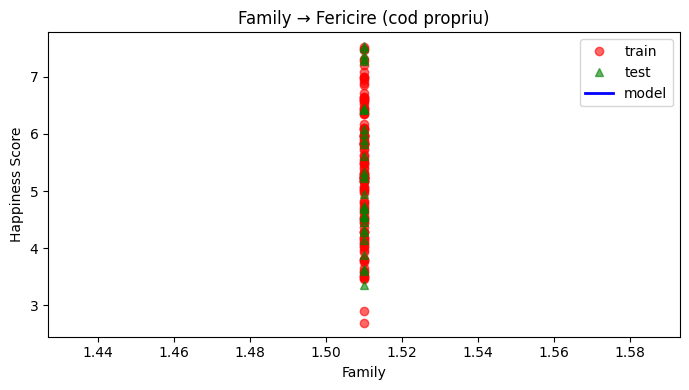

In [6]:
my_reg = myRegression.MyLinearUnivariateRegression()
my_reg.fit(trFamIn, trFamOut)
w0fo, w1fo = my_reg.intercept_, my_reg.coef_
print(f"Model Family (cod propriu):  f(x) = {w0fo:.4f} + {w1fo:.4f} * x")
predFamOwn = my_reg.predict(teFamIn)
evalMetricsManual(teFamOut, predFamOwn, "[cod propriu Family]")
xref = np.linspace(min(trFamIn), max(trFamIn), 200)
yref = w0fo + w1fo * xref
plotScatter(trFamIn, trFamOut, teFamIn, teFamOut, xref, yref, 'Family', 'Family → Fericire (cod propriu)')

  Loaded 155 rows, skipped 0 rows cu date invalide
Model GDP+Freedom:  intercept=2.5284  coefs=[1.87633874 2.31474875]
f(x) = 2.5284 + 1.8763 * GDP + 2.3147 * Freedom
[sklearn GDP+Freedom]  MSE = 0.2778  |  MAE = 0.4386


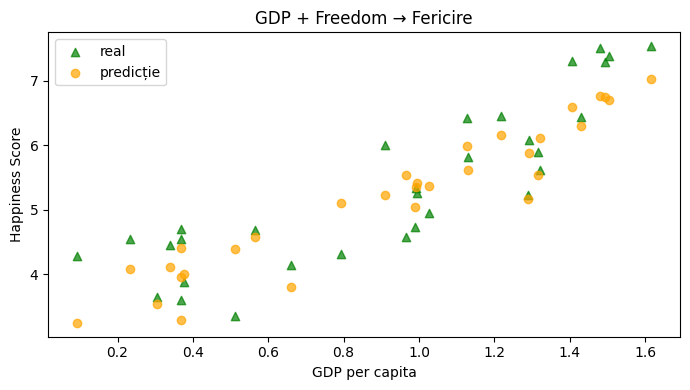

In [7]:
inputs_mv, outputs_mv = loadData(filePath1, ['Economy..GDP.per.Capita.', 'Freedom'], 'Happiness.Score')
trMvIn, trMvOut, teMvIn, teMvOut = splitTrainTest(inputs_mv, outputs_mv)

reg_mv = linear_model.LinearRegression()
reg_mv.fit(trMvIn, trMvOut)
print(f"Model GDP+Freedom:  intercept={reg_mv.intercept_:.4f}  coefs={reg_mv.coef_}")
print(f"f(x) = {reg_mv.intercept_:.4f} + {reg_mv.coef_[0]:.4f} * GDP + {reg_mv.coef_[1]:.4f} * Freedom")

predMv = reg_mv.predict(teMvIn)
evalMetrics(teMvOut, predMv, "[sklearn GDP+Freedom]")

fig, ax = plt.subplots(figsize=(7, 4))
gdp_test = [r[0] for r in teMvIn]
ax.scatter(gdp_test, teMvOut,  c='green', marker='^', alpha=0.7, label='real')
ax.scatter(gdp_test, predMv,   c='orange', marker='o', alpha=0.7, label='predicție')
ax.set_xlabel('GDP per capita'); ax.set_ylabel('Happiness Score')
ax.set_title('GDP + Freedom → Fericire'); ax.legend(); plt.tight_layout(); plt.show()

Model GDP+Freedom (cod propriu):  intercept=2.5284  coefs=[1.876338736009061, 2.3147487477232187]
f(x) = 2.5284 + 1.8763 * GDP + 2.3147 * Freedom
[cod propriu GDP+Freedom]  MSE manual = 0.2778  |  MAE manual = 0.4386


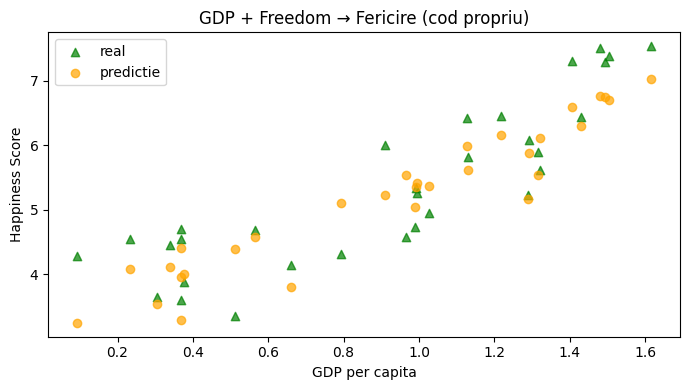

In [8]:
my_reg = myRegression.MyLinearBivariateRegression()
my_reg.fit(trMvIn, trMvOut)
print(f"Model GDP+Freedom (cod propriu):  intercept={my_reg.intercept_:.4f}  coefs={my_reg.coef_}")
print(f"f(x) = {my_reg.intercept_:.4f} + {my_reg.coef_[0]:.4f} * GDP + {my_reg.coef_[1]:.4f} * Freedom")
predMvOwn = my_reg.predict(teMvIn)
evalMetricsManual(teMvOut, predMvOwn, "[cod propriu GDP+Freedom]")
fig, ax = plt.subplots(figsize=(7, 4))
gdp_test = [r[0] for r in teMvIn]
ax.scatter(gdp_test, teMvOut,  c='green', marker='^', alpha=0.7, label='real')
ax.scatter(gdp_test, predMvOwn,   c='orange', marker='o', alpha=0.7, label='predictie')
ax.set_xlabel('GDP per capita'); ax.set_ylabel('Happiness Score')
ax.set_title('GDP + Freedom → Fericire (cod propriu)')
ax.legend()
plt.tight_layout()
plt.show()

  Loaded 155 rows, skipped 0 rows cu date invalide
  GDP 2:  intercept=3.2008  coefs=[2.1503461]
  [GDP 2]  MSE = 0.4142  |  MAE = 0.5588


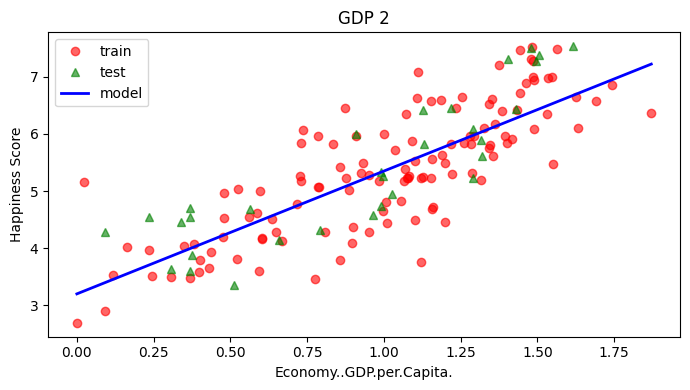

  Loaded 155 rows, skipped 0 rows cu date invalide
  Family 2:  intercept=2.0390  coefs=[2.80491362]
  [Family 2]  MSE = 0.6051  |  MAE = 0.6263


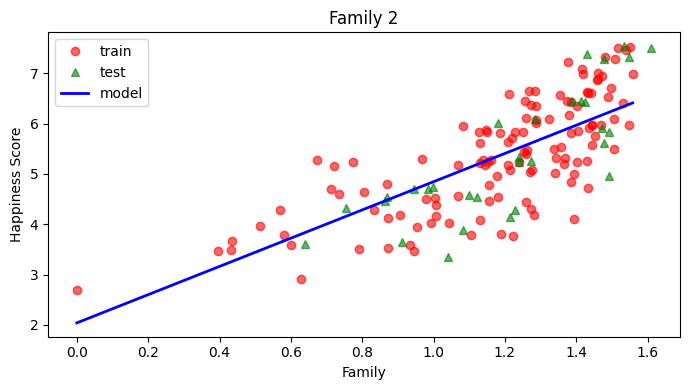

  Loaded 155 rows, skipped 0 rows cu date invalide
  GDP+Freedom 2:  intercept=3.2008  coefs=[-68616.18596733 137236.67264356]
  [GDP+Freedom 2]  MSE = 0.4142  |  MAE = 0.5588


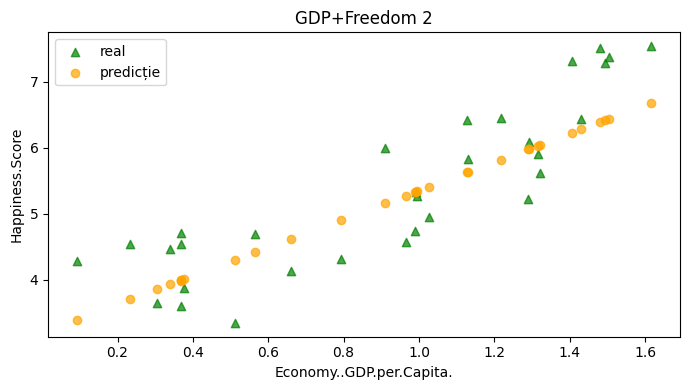

In [11]:
import os

filePath2 = 'data/v2_world-happiness-report-2017.csv'
filePath3 = 'data/v3_world-happiness-report-2017.csv'

def run(filePath, inputVars, outputVar, label):
    if not os.path.exists(filePath):
        return
    inputs, outputs = loadData(filePath, inputVars, outputVar)
    trIn, trOut, teIn, teOut = splitTrainTest(inputs, outputs)
    xxTr = [[x] for x in trIn] 
    xxTe = [[x] for x in teIn] 
    reg = linear_model.LinearRegression()
    reg.fit(xxTr, trOut)
    pred = reg.predict(xxTe)
    print(f"  {label}:  intercept={reg.intercept_:.4f}  coefs={reg.coef_}")
    evalMetrics(teOut, pred, f"  [{label}]")
    xref = np.linspace(min(trIn), max(trIn), 200)
    yref = reg.intercept_ + reg.coef_[0] * xref
    feat = inputVars if isinstance(inputVars, str) else inputVars[0]
    plotScatter(trIn, trOut, teIn, teOut, xref, yref, feat, label)
        
def runBivariate(filePath, inputVars, outputVar, label):
    if not os.path.exists(filePath):
        return
    inputs, outputs = loadData(filePath, inputVars, outputVar)
    trIn, trOut, teIn, teOut = splitTrainTest(inputs, outputs)
    reg = linear_model.LinearRegression()
    reg.fit(trIn, trOut)
    pred = reg.predict(teIn)
    print(f"  {label}:  intercept={reg.intercept_:.4f}  coefs={reg.coef_}")
    evalMetrics(teOut, pred, f"  [{label}]")
    fig, ax = plt.subplots(figsize=(7, 4))
    gdp_test = [r[0] for r in teIn]
    ax.scatter(gdp_test, teOut,  c='green', marker='^', alpha=0.7, label='real')
    ax.scatter(gdp_test, pred,   c='orange', marker='o', alpha=0.7, label='predicție')
    ax.set_xlabel(inputVars[0]); ax.set_ylabel(outputVar)
    ax.set_title(label); ax.legend(); plt.tight_layout(); plt.show()


run(filePath2, 'Economy..GDP.per.Capita.', 'Happiness.Score', 'GDP 2')
run(filePath2, 'Family', 'Happiness.Score', 'Family 2')
runBivariate(filePath2, ['Economy..GDP.per.Capita.', 'Freedom'], 'Happiness.Score','GDP+Freedom 2')

  Loaded 152 rows, skipped 3 rows cu date invalide
  GDP 3:  intercept=3.2591  coefs=[2.10920754]
  [GDP 3]  MSE = 0.5012  |  MAE = 0.5870


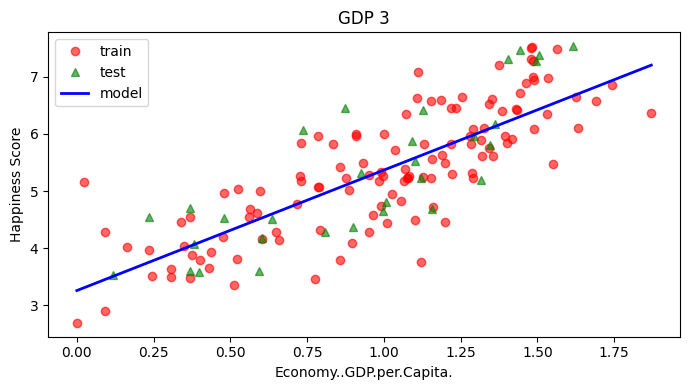

  Loaded 155 rows, skipped 0 rows cu date invalide
  Family 3:  intercept=2.0390  coefs=[2.80491362]
  [Family 3]  MSE = 0.6051  |  MAE = 0.6263


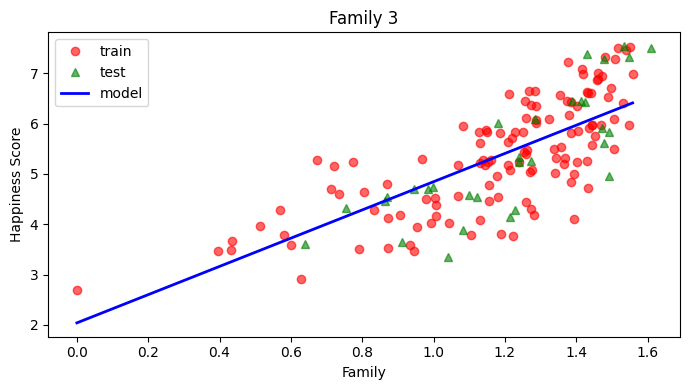

  Loaded 149 rows, skipped 6 rows cu date invalide
  GDP+Freedom 3:  intercept=2.5467  coefs=[1.92085903 2.24055151]
  [GDP+Freedom 3]  MSE = 0.3239  |  MAE = 0.4798


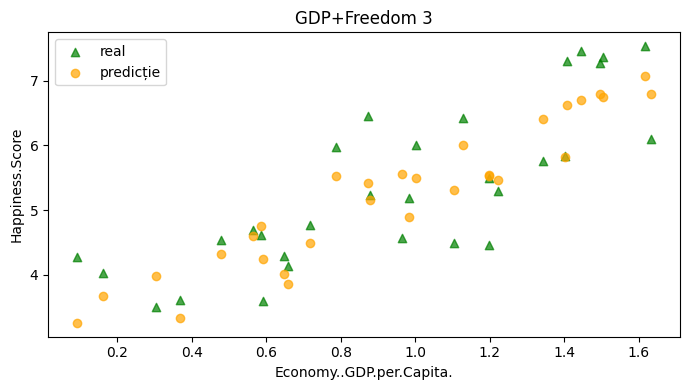

In [12]:
run(filePath3, 'Economy..GDP.per.Capita.', 'Happiness.Score', 'GDP 3')
run(filePath3, 'Family', 'Happiness.Score', 'Family 3')
runBivariate(filePath3, ['Economy..GDP.per.Capita.', 'Freedom'], 'Happiness.Score','GDP+Freedom 3')